# Author Embeddings: Evaluation & Model Comparison

This notebook evaluates the quality of author embeddings by:
1. **Co-author proximity test** - Do co-authors end up closer in embedding space than random pairs?
2. **Model comparison** - SPECTER vs MiniLM (all-MiniLM-L6-v2) on the same data

In [1]:
!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn scipy tqdm plotly

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

/home/milosz/author-embeddings/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
# Load publications with abstracts
titles_df = pd.read_csv("data/titles_with_abstracts.csv")
scientists_df = pd.read_csv("data/scientists_with_identifiers.csv")

# Filter scientists who have publications
scientists_df = scientists_df[
    scientists_df["orcid"].isin(titles_df["main_author_orcid"])
]

print(f"Scientists with publications: {len(scientists_df)}")
print(f"Total publications: {len(titles_df)}")
print(f"Publications with abstracts: {titles_df['abstract'].notna().sum()}")

Scientists with publications: 115
Total publications: 3440
Publications with abstracts: 3440


## 2. Build Co-authorship Ground Truth

Extract pairs of scientists who have co-authored at least one paper together.

In [3]:
def extract_coauthor_pairs(titles_df, scientists_df):
    """
    Extract pairs of scientists (from our dataset) who have co-authored together.
    Returns set of tuples (orcid1, orcid2) where orcid1 < orcid2 (to avoid duplicates).
    """
    known_orcids = set(scientists_df['orcid'].dropna().astype(str))
    coauthor_pairs = set()
    coauthor_counts = {}  # Track how many papers each pair co-authored
    
    for _, row in titles_df.iterrows():
        main_orcid = str(row['main_author_orcid']) if pd.notna(row['main_author_orcid']) else None
        
        if not main_orcid or main_orcid not in known_orcids:
            continue
            
        # Parse co-author ORCIDs
        co_orcids_raw = row.get('co_author_orcids', '')
        if pd.isna(co_orcids_raw) or not co_orcids_raw:
            continue
            
        co_orcids = [o.strip() for o in str(co_orcids_raw).split(',') if o.strip()]
        
        for co_orcid in co_orcids:
            if co_orcid in known_orcids and co_orcid != main_orcid:
                # Create ordered pair to avoid duplicates
                pair = tuple(sorted([main_orcid, co_orcid]))
                coauthor_pairs.add(pair)
                coauthor_counts[pair] = coauthor_counts.get(pair, 0) + 1
    
    return coauthor_pairs, coauthor_counts

coauthor_pairs, coauthor_counts = extract_coauthor_pairs(titles_df, scientists_df)
print(f"Found {len(coauthor_pairs)} unique co-author pairs among our scientists")

# Show distribution of co-authorship strength
if coauthor_counts:
    counts = list(coauthor_counts.values())
    print(f"Co-authorship frequency: min={min(counts)}, max={max(counts)}, mean={np.mean(counts):.1f}")

Found 57 unique co-author pairs among our scientists
Co-authorship frequency: min=2, max=20, mean=4.4


## 3. Generate Author Embeddings

Create author embeddings by aggregating their publication texts (titles + abstracts).

In [4]:
def build_author_corpus(titles_df, scientists_df, use_abstracts=True):
    """
    Build text corpus for each author by concatenating their publications.
    Returns dict: orcid -> concatenated text
    """
    author_texts = {}
    
    for _, sci in scientists_df.iterrows():
        orcid = str(sci['orcid'])
        works = titles_df[titles_df['main_author_orcid'] == orcid]
        
        chunks = []
        for _, w in works.iterrows():
            title = str(w['title']) if pd.notna(w['title']) else ""
            chunks.append(title)
            
            if use_abstracts and pd.notna(w.get('abstract')):
                chunks.append(str(w['abstract']))
        
        text = " ".join(chunks).strip()
        if text:
            author_texts[orcid] = text
    
    return author_texts

# Build corpora
author_texts_titles = build_author_corpus(titles_df, scientists_df, use_abstracts=False)
author_texts_full = build_author_corpus(titles_df, scientists_df, use_abstracts=True)

print(f"Authors with text corpus: {len(author_texts_full)}")

Authors with text corpus: 115


In [5]:
def generate_embeddings(author_texts, model):
    """
    Generate embeddings for each author using the given model.
    Returns dict: orcid -> embedding vector
    """
    orcids = list(author_texts.keys())
    texts = [author_texts[o] for o in orcids]
    
    embeddings = model.encode(texts, show_progress_bar=True)
    
    return {orcid: emb for orcid, emb in zip(orcids, embeddings)}

print("Loading models...")
model_specter = SentenceTransformer('allenai-specter')
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')

print("\nGenerating SPECTER embeddings (titles + abstracts)...")
emb_specter = generate_embeddings(author_texts_full, model_specter)

print("\nGenerating MiniLM embeddings (titles + abstracts)...")
emb_minilm = generate_embeddings(author_texts_full, model_minilm)

print(f"\nGenerated embeddings for {len(emb_specter)} authors")
print(f"SPECTER embedding dimension: {len(list(emb_specter.values())[0])}")
print(f"MiniLM embedding dimension: {len(list(emb_minilm.values())[0])}")

Loading models...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 495.05it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/allenai-specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 381.62it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Generating SPECTER embeddings (titles + abstracts)...


Batches: 100%|██████████| 4/4 [00:50<00:00, 12.52s/it]



Generating MiniLM embeddings (titles + abstracts)...


Batches: 100%|██████████| 4/4 [00:04<00:00,  1.10s/it]


Generated embeddings for 115 authors
SPECTER embedding dimension: 768
MiniLM embedding dimension: 384


## 4. Evaluation: Co-author Proximity Test

**Hypothesis**: If embeddings capture research similarity, co-authors should be closer in embedding space than random pairs.

**Method**:
1. Compute cosine similarity for all co-author pairs
2. Compute cosine similarity for random (non-co-author) pairs
3. Compare distributions using statistical tests

In [6]:
def evaluate_coauthor_proximity(embeddings, coauthor_pairs, n_random_samples=1000):
    """
    Evaluate if co-authors are closer in embedding space than random pairs.
    
    Returns:
        coauthor_sims: list of similarities for co-author pairs
        random_sims: list of similarities for random pairs
        stats_result: statistical test result
    """
    orcids = list(embeddings.keys())
    
    # Filter co-author pairs to those we have embeddings for
    valid_coauthor_pairs = [
        (a, b) for a, b in coauthor_pairs 
        if a in embeddings and b in embeddings
    ]
    
    if not valid_coauthor_pairs:
        print("No valid co-author pairs found!")
        return [], [], None
    
    # Compute co-author similarities
    coauthor_sims = []
    for a, b in valid_coauthor_pairs:
        sim = cosine_similarity([embeddings[a]], [embeddings[b]])[0][0]
        coauthor_sims.append(sim)
    
    # Generate random non-co-author pairs
    coauthor_set = set(valid_coauthor_pairs)
    random_sims = []
    attempts = 0
    max_attempts = n_random_samples * 10
    
    while len(random_sims) < n_random_samples and attempts < max_attempts:
        a, b = np.random.choice(orcids, 2, replace=False)
        pair = tuple(sorted([a, b]))
        
        if pair not in coauthor_set:
            sim = cosine_similarity([embeddings[a]], [embeddings[b]])[0][0]
            random_sims.append(sim)
        attempts += 1
    
    # Statistical test (Mann-Whitney U - non-parametric)
    if coauthor_sims and random_sims:
        stat_result = stats.mannwhitneyu(
            coauthor_sims, random_sims, 
            alternative='greater'  # Test if co-authors have HIGHER similarity
        )
    else:
        stat_result = None
    
    return coauthor_sims, random_sims, stat_result

print("Evaluating SPECTER embeddings...")
specter_coauth, specter_random, specter_stat = evaluate_coauthor_proximity(
    emb_specter, coauthor_pairs
)

print("Evaluating MiniLM embeddings...")
minilm_coauth, minilm_random, minilm_stat = evaluate_coauthor_proximity(
    emb_minilm, coauthor_pairs
)

Evaluating SPECTER embeddings...
Evaluating MiniLM embeddings...


In [7]:
def print_evaluation_results(name, coauth_sims, random_sims, stat_result):
    """Print evaluation summary."""
    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"{'='*60}")
    print(f"Co-author pairs evaluated: {len(coauth_sims)}")
    print(f"Random pairs sampled: {len(random_sims)}")
    print(f"\nCo-author similarity:  mean={np.mean(coauth_sims):.4f}, std={np.std(coauth_sims):.4f}")
    print(f"Random similarity:     mean={np.mean(random_sims):.4f}, std={np.std(random_sims):.4f}")
    print(f"\nDifference: {np.mean(coauth_sims) - np.mean(random_sims):.4f}")
    
    if stat_result:
        print(f"\nMann-Whitney U test (co-authors > random):")
        print(f"  U-statistic: {stat_result.statistic:.2f}")
        print(f"  p-value: {stat_result.pvalue:.2e}")
        if stat_result.pvalue < 0.05:
            print(f"  Result: SIGNIFICANT - Co-authors ARE closer than random pairs")
        else:
            print(f"  Result: NOT significant")

print_evaluation_results("SPECTER", specter_coauth, specter_random, specter_stat)
print_evaluation_results("MiniLM", minilm_coauth, minilm_random, minilm_stat)


Model: SPECTER
Co-author pairs evaluated: 57
Random pairs sampled: 1000

Co-author similarity:  mean=0.7871, std=0.1315
Random similarity:     mean=0.6238, std=0.1068

Difference: 0.1633

Mann-Whitney U test (co-authors > random):
  U-statistic: 47385.00
  p-value: 1.82e-17
  Result: SIGNIFICANT - Co-authors ARE closer than random pairs

Model: MiniLM
Co-author pairs evaluated: 57
Random pairs sampled: 1000

Co-author similarity:  mean=0.4187, std=0.2404
Random similarity:     mean=0.1091, std=0.1334

Difference: 0.3096

Mann-Whitney U test (co-authors > random):
  U-statistic: 48729.00
  p-value: 9.11e-20
  Result: SIGNIFICANT - Co-authors ARE closer than random pairs


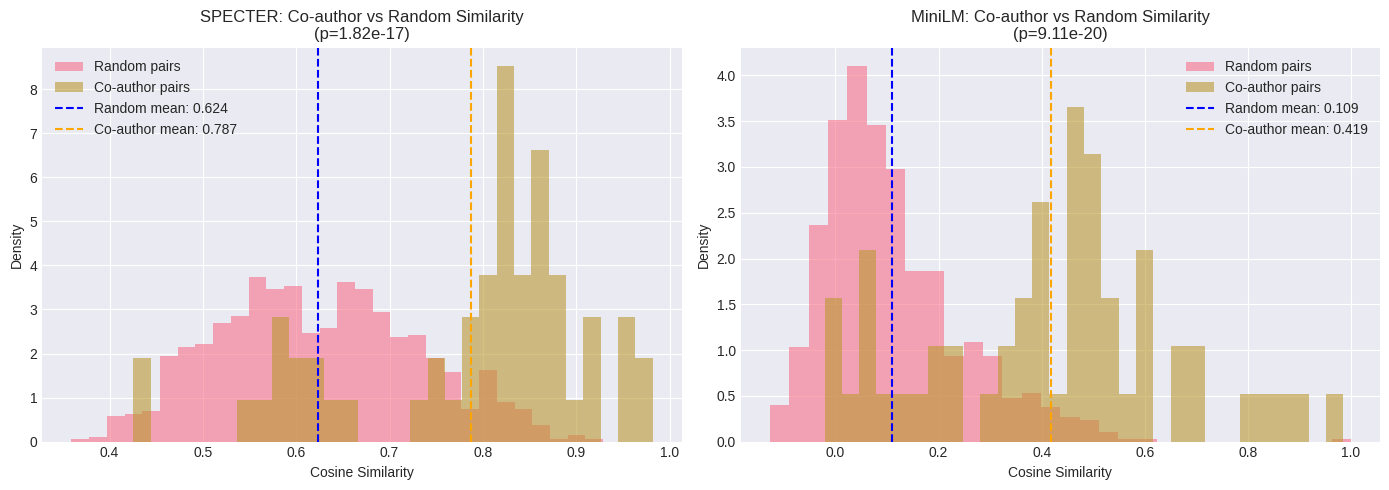

In [8]:
# Visualization: Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SPECTER
ax = axes[0]
ax.hist(specter_random, bins=30, alpha=0.6, label='Random pairs', density=True)
ax.hist(specter_coauth, bins=30, alpha=0.6, label='Co-author pairs', density=True)
ax.axvline(np.mean(specter_random), color='blue', linestyle='--', label=f'Random mean: {np.mean(specter_random):.3f}')
ax.axvline(np.mean(specter_coauth), color='orange', linestyle='--', label=f'Co-author mean: {np.mean(specter_coauth):.3f}')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Density')
ax.set_title(f'SPECTER: Co-author vs Random Similarity\n(p={specter_stat.pvalue:.2e})')
ax.legend()

# MiniLM
ax = axes[1]
ax.hist(minilm_random, bins=30, alpha=0.6, label='Random pairs', density=True)
ax.hist(minilm_coauth, bins=30, alpha=0.6, label='Co-author pairs', density=True)
ax.axvline(np.mean(minilm_random), color='blue', linestyle='--', label=f'Random mean: {np.mean(minilm_random):.3f}')
ax.axvline(np.mean(minilm_coauth), color='orange', linestyle='--', label=f'Co-author mean: {np.mean(minilm_coauth):.3f}')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Density')
ax.set_title(f'MiniLM: Co-author vs Random Similarity\n(p={minilm_stat.pvalue:.2e})')
ax.legend()

plt.tight_layout()
plt.savefig('coauthor_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Comparison: SPECTER vs MiniLM

Compare the two models across multiple metrics.

In [9]:
# Effect size (Cohen's d)
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

specter_effect = cohens_d(specter_coauth, specter_random)
minilm_effect = cohens_d(minilm_coauth, minilm_random)

print("Model Comparison Summary")
print("="*60)
print(f"{'Metric':<30} {'SPECTER':>12} {'MiniLM':>12}")
print("-"*60)
print(f"{'Embedding dimension':<30} {768:>12} {384:>12}")
print(f"{'Co-author mean similarity':<30} {np.mean(specter_coauth):>12.4f} {np.mean(minilm_coauth):>12.4f}")
print(f"{'Random mean similarity':<30} {np.mean(specter_random):>12.4f} {np.mean(minilm_random):>12.4f}")
print(f"{'Difference (co-auth - random)':<30} {np.mean(specter_coauth)-np.mean(specter_random):>12.4f} {np.mean(minilm_coauth)-np.mean(minilm_random):>12.4f}")
print(f"{'Effect size (Cohen d)':<30} {specter_effect:>12.4f} {minilm_effect:>12.4f}")
print(f"{'p-value':<30} {specter_stat.pvalue:>12.2e} {minilm_stat.pvalue:>12.2e}")

Model Comparison Summary
Metric                              SPECTER       MiniLM
------------------------------------------------------------
Embedding dimension                     768          384
Co-author mean similarity            0.7871       0.4187
Random mean similarity               0.6238       0.1091
Difference (co-auth - random)        0.1633       0.3096
Effect size (Cohen d)                1.5069       2.1903
p-value                            1.82e-17     9.11e-20


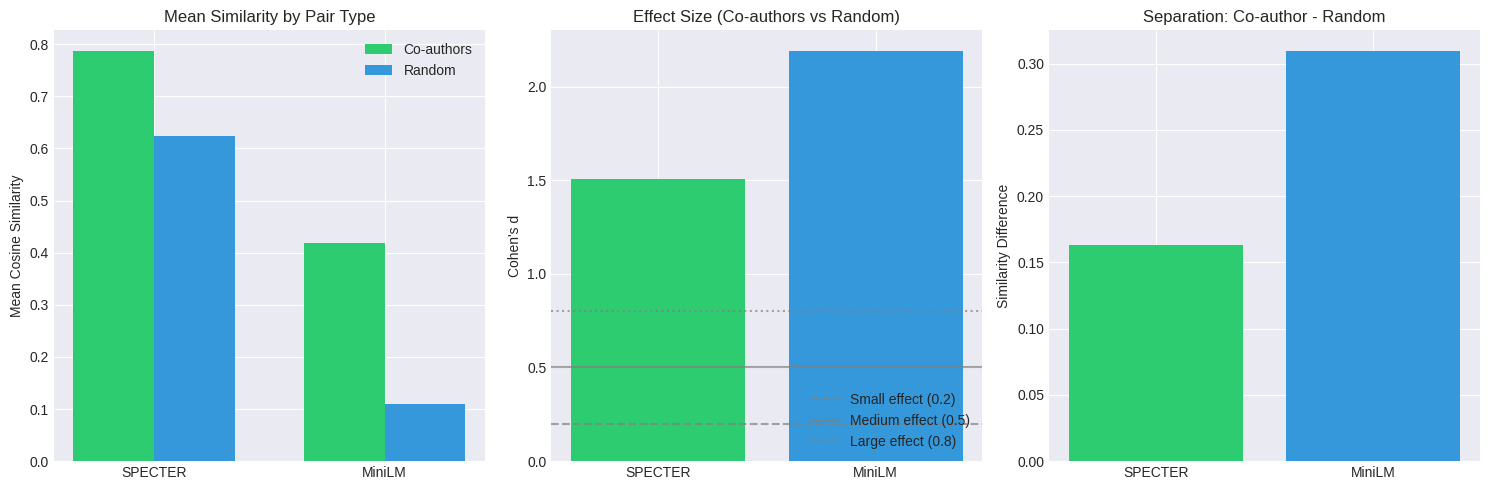

In [10]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['SPECTER', 'MiniLM']
colors = ['#2ecc71', '#3498db']

# Mean similarity comparison
ax = axes[0]
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [np.mean(specter_coauth), np.mean(minilm_coauth)], width, label='Co-authors', color=colors[0])
ax.bar(x + width/2, [np.mean(specter_random), np.mean(minilm_random)], width, label='Random', color=colors[1])
ax.set_ylabel('Mean Cosine Similarity')
ax.set_title('Mean Similarity by Pair Type')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Effect size comparison
ax = axes[1]
ax.bar(models, [specter_effect, minilm_effect], color=colors)
ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.7, label='Small effect (0.2)')
ax.axhline(y=0.5, color='gray', linestyle='-', alpha=0.7, label='Medium effect (0.5)')
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.7, label='Large effect (0.8)')
ax.set_ylabel("Cohen's d")
ax.set_title('Effect Size (Co-authors vs Random)')
ax.legend(loc='lower right')

# Separation quality (difference in means)
ax = axes[2]
diffs = [np.mean(specter_coauth)-np.mean(specter_random), np.mean(minilm_coauth)-np.mean(minilm_random)]
ax.bar(models, diffs, color=colors)
ax.set_ylabel('Similarity Difference')
ax.set_title('Separation: Co-author - Random')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Between Models

Do SPECTER and MiniLM agree on which authors are similar?

In [11]:
# Compute full similarity matrices
common_orcids = sorted(set(emb_specter.keys()) & set(emb_minilm.keys()))

specter_matrix = np.array([emb_specter[o] for o in common_orcids])
minilm_matrix = np.array([emb_minilm[o] for o in common_orcids])

specter_sim_matrix = cosine_similarity(specter_matrix)
minilm_sim_matrix = cosine_similarity(minilm_matrix)

# Extract upper triangle (unique pairs)
triu_idx = np.triu_indices(len(common_orcids), k=1)
specter_sims_all = specter_sim_matrix[triu_idx]
minilm_sims_all = minilm_sim_matrix[triu_idx]

# Correlation
correlation, p_value = stats.pearsonr(specter_sims_all, minilm_sims_all)

print(f"Correlation between SPECTER and MiniLM similarities:")
print(f"  Pearson r = {correlation:.4f}")
print(f"  p-value = {p_value:.2e}")

Correlation between SPECTER and MiniLM similarities:
  Pearson r = 0.7286
  p-value = 0.00e+00


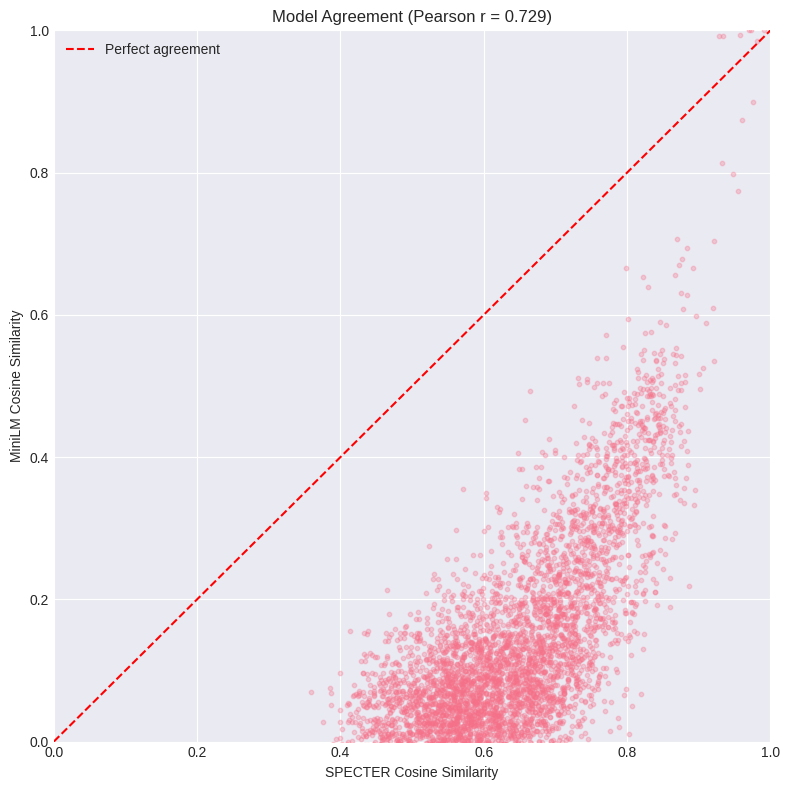

In [12]:
# Scatter plot of similarities
fig, ax = plt.subplots(figsize=(8, 8))

# Sample for visualization (too many points otherwise)
n_sample = min(5000, len(specter_sims_all))
idx = np.random.choice(len(specter_sims_all), n_sample, replace=False)

ax.scatter(specter_sims_all[idx], minilm_sims_all[idx], alpha=0.3, s=10)
ax.plot([0, 1], [0, 1], 'r--', label='Perfect agreement')

ax.set_xlabel('SPECTER Cosine Similarity')
ax.set_ylabel('MiniLM Cosine Similarity')
ax.set_title(f'Model Agreement (Pearson r = {correlation:.3f})')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('model_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary & Conclusions

In [13]:
print("="*70)
print("EVALUATION SUMMARY")
print("="*70)
print(f"\nDataset: {len(common_orcids)} authors, {len(coauthor_pairs)} co-author pairs")
print("\n" + "-"*70)
print("CO-AUTHOR PROXIMITY TEST")
print("-"*70)
print("\nBoth models show that co-authors have HIGHER similarity than random pairs:")
print(f"  SPECTER: +{np.mean(specter_coauth)-np.mean(specter_random):.4f} (effect size d={specter_effect:.2f})")
print(f"  MiniLM:  +{np.mean(minilm_coauth)-np.mean(minilm_random):.4f} (effect size d={minilm_effect:.2f})")

winner_effect = "SPECTER" if specter_effect > minilm_effect else "MiniLM"
print(f"\n  Better separation: {winner_effect}")

print("\n" + "-"*70)
print("MODEL COMPARISON")
print("-"*70)
print(f"\n  Embedding dimensions: SPECTER=768, MiniLM=384")
print(f"  Model agreement (Pearson r): {correlation:.3f}")
print(f"\n  SPECTER: Trained on scientific papers (Semantic Scholar)")
print(f"  MiniLM: General-purpose, faster, smaller")

print("\n" + "-"*70)
print("INTERPRETATION")
print("-"*70)
if specter_stat.pvalue < 0.05 and minilm_stat.pvalue < 0.05:
    print("\n  Both models successfully capture research similarity -")
    print("  co-authors are significantly closer in embedding space.")
    print("\n  This validates the use of text embeddings for author profiling.")

EVALUATION SUMMARY

Dataset: 115 authors, 57 co-author pairs

----------------------------------------------------------------------
CO-AUTHOR PROXIMITY TEST
----------------------------------------------------------------------

Both models show that co-authors have HIGHER similarity than random pairs:
  SPECTER: +0.1633 (effect size d=1.51)
  MiniLM:  +0.3096 (effect size d=2.19)

  Better separation: MiniLM

----------------------------------------------------------------------
MODEL COMPARISON
----------------------------------------------------------------------

  Embedding dimensions: SPECTER=768, MiniLM=384
  Model agreement (Pearson r): 0.729

  SPECTER: Trained on scientific papers (Semantic Scholar)
  MiniLM: General-purpose, faster, smaller

----------------------------------------------------------------------
INTERPRETATION
----------------------------------------------------------------------

  Both models successfully capture research similarity -
  co-authors are sign

## 8. Save Results

In [14]:
# Save evaluation results to CSV
results_df = pd.DataFrame({
    'Model': ['SPECTER', 'MiniLM'],
    'Embedding_Dim': [768, 384],
    'Coauthor_Pairs': [len(specter_coauth), len(minilm_coauth)],
    'Coauthor_Mean_Sim': [np.mean(specter_coauth), np.mean(minilm_coauth)],
    'Random_Mean_Sim': [np.mean(specter_random), np.mean(minilm_random)],
    'Difference': [np.mean(specter_coauth)-np.mean(specter_random), np.mean(minilm_coauth)-np.mean(minilm_random)],
    'Effect_Size_d': [specter_effect, minilm_effect],
    'p_value': [specter_stat.pvalue, minilm_stat.pvalue]
})

results_df.to_csv('evaluation_results.csv', index=False)
print("Results saved to evaluation_results.csv")
display(results_df)

Results saved to evaluation_results.csv


,Model,Embedding_Dim,Coauthor_Pairs,Coauthor_Mean_Sim,Random_Mean_Sim,Difference,Effect_Size_d,p_value
0,SPECTER,768,57,0.787089,0.623793,0.163296,1.506933,1.819948e-17
1,MiniLM,384,57,0.418656,0.109059,0.309596,2.190340,9.110186e-20
